In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

csv_file = '../data/logs/training_log_20260409_0130.csv'
json_file = '../data/models/model_gen_64_score_135_20260409_013038.json'

df = pd.read_csv(csv_file)
with open(json_file, 'r') as file:
    model_data = json.load(file)

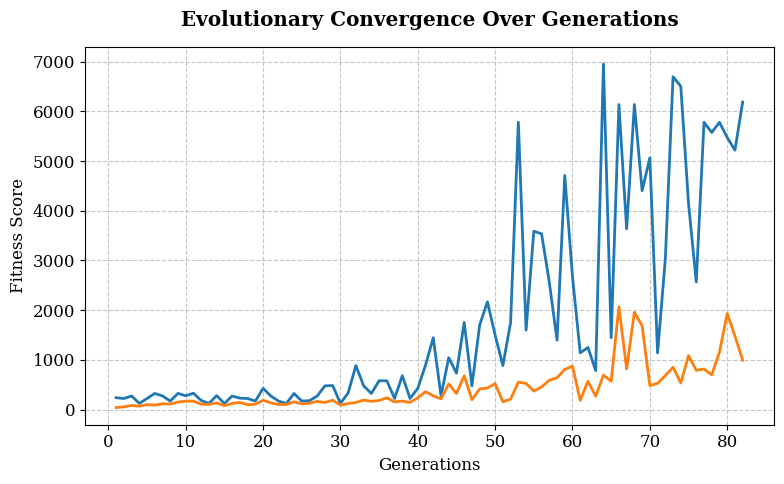

In [ ]:
fig1, ax1 = plt.subplots(figsize = (8,5))
ax1.plot(df['Generation'], df['Max Fitness'], label='Max Fitness', color='#1f77b4', linewidth=2)
ax1.plot(df['Generation'], df['Avg Fitness'], label='Average Fitness', color='#ff7f0e', linewidth=2)

ax1.set_title('Evolutionary Convergence Over Generations', fontweight='bold', pad=15)
ax1.set_xlabel('Generations')
ax1.set_ylabel('Fitness Score')
ax1.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
fig1.savefig('convergance_plot.pdf', format='pdf', bbox_inches='tight')

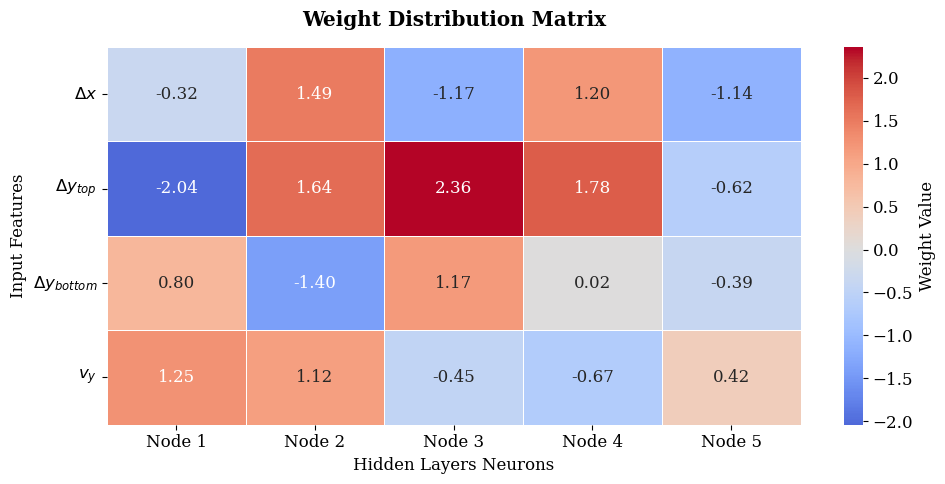

In [ ]:
w1_raw = np.array(model_data['weights']['w1'])
if w1_raw.shape == (5,4):
    w1_matrix = w1_raw.T
else:
    w1_matrix = w1_raw
inputs_labels = [r'$\Delta x$', r'$\Delta y_{top}$', r'$\Delta y_{bottom}$', r'$v_y$']
hidden_labels = ['Node 1', 'Node 2', 'Node 3', 'Node 4', 'Node 5']

fig2, ax2 = plt.subplots(figsize=(10,5))
sns.heatmap(w1_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
           xticklabels=hidden_labels, yticklabels=inputs_labels,
           cbar_kws={'label': 'Weight Value'}, linewidths=0.5, ax=ax2)
ax2.set_title('Weight Distribution Matrix', pad=15, fontweight='bold')
ax2.set_xlabel('Hidden Layers Neurons')
ax2.set_ylabel('Input Features')
plt.yticks(rotation=0) 
plt.tight_layout()
fig2.savefig('heatmap_w1.pdf', format='pdf', bbox_inches='tight')

In [ ]:
milestones = [1, 10, 30, 50, 64]
df_table = df[df['Generation'].isin(milestones)][['Generation', 'Gen Best Score', 'Max Fitness', 'Lifespan (Minutes)']]
df_table = df_table.rename(columns={
    'Gen Best Score': 'Peak Score',
    'Max Fitness': 'Max Fitness',
    'Lifespan (Minutes)': 'Cumulative Time (min)'
})

df_table['Cumulative Time (min)'] = df_table['Cumulative Time (min)'].round(2)

print("\n DATA WITH PROCESSED DATA")
print("=" * 65)
print(df_table.to_string(index=False))
print("=" * 65)


 DATA WITH PROCESSED DATA
 Generation  Peak Score  Max Fitness  Cumulative Time (min)
          1           3          238                   0.08
         10           4          277                   0.09
         30           1          124                   0.04
         50          28         1497                   0.57
         64         135         6954                  18.77
